In [1]:
import bottleneck as bn
import matplotlib
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import scienceplots
import scipy
import scipy.signal
import scipy.special
import scipy.stats
import sklearn.decomposition
import astropy.io
import datetime
import astropy.time
import pandas as pd

from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use(['science', 'nature', 'notebook', 'grid', 'high-vis'])

figsize_short = (8, 4)
figsize_normal = (8, 6)
figsize_tall = (8, 8)
plt.rcParams['figure.figsize'] = figsize_short
plt.rcParams['axes.labelpad'] = 6.0
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.8
plt.rcParams['legend.edgecolor'] = 'none'


title_font = {'fontsize': 16, 'weight': 'bold', 'style': 'italic'}
path_effect = [pe.withStroke(linewidth=2.0, foreground="k")]

read_path = 'docs/Data/'
save_path = 'docs/Figure/'

perula_df = pd.read_csv(read_path + 'matlab_perula.txt', header = None, sep = '\s+')
matlab_perula = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_perula', np.array(perula_df))

jet_df = pd.read_csv(read_path + 'matlab_jet.txt', header = None, sep = '\s+')
matlab_jet = matplotlib.colors.LinearSegmentedColormap.from_list('matlab_jet', np.array(jet_df))

%matplotlib ipympl

<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_96032/3118345031.py:41: SyntaxWarning: invalid escape sequence '\s'
  perula_df = pd.read_csv(read_path + 'matlab_perula.txt', header = None, sep = '\s+')
/tmp/ipykernel_96032/3118345031.py:44: SyntaxWarning: invalid escape sequence '\s'
  jet_df = pd.read_csv(read_path + 'matlab_jet.txt', header = None, sep = '\s+')


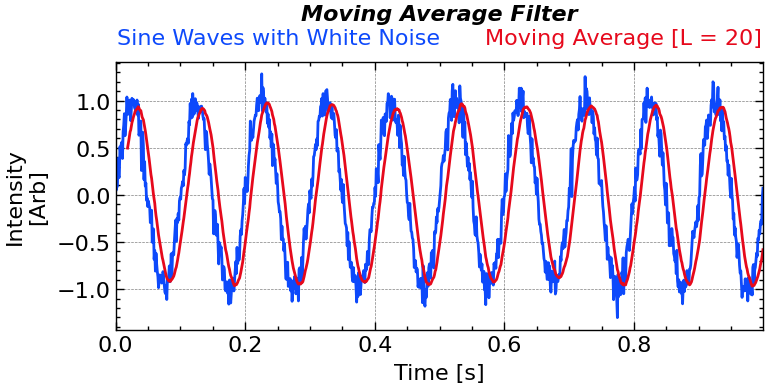

In [32]:
plt.close()
plt.close()
N = 2 ** 10

t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
sig = np.sin(2 * np.pi * 10 * t) + 0.1 * np.random.randn(N)

plt.figure(figsize=figsize_short)
ax1 = plt.subplot(1, 1, 1)
ax1.plot(t, sig, color='C0', label='Sine Waves with White Noise')

sig_ma = bn.move_mean(sig, 20)
ax1.plot(t, sig_ma, 'C1-', label='Moving Average [L = 20]')
ax1.legend(loc = 'upper center', ncol = 5, labelcolor="linecolor", handlelength = 0, handletextpad = 0, frameon = False, bbox_to_anchor=(0.5, 1.2))
ax1.set_title('Moving Average Filter', fontdict=title_font, pad = 30)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity\n[Arb]')
plt.tight_layout()
ax1.autoscale(enable=True, axis='x', tight=True)
plt.savefig(save_path + 'figure_moving_average' + '.png', bbox_inches='tight', dpi=300)

plt.show()

In [47]:
scipy.signal.lfilter

<function scipy.signal._signaltools.lfilter(b, a, x, axis=-1, zi=None)>

[-36.87856014  32.37424447  16.65554763 ...   0.64079998   0.24860884
  -0.51220258]


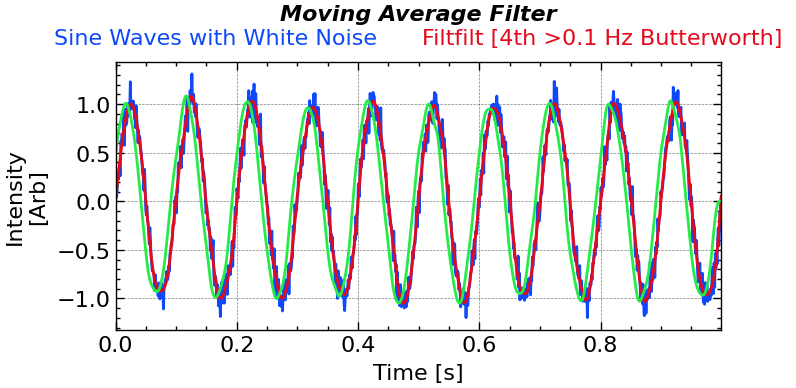

In [46]:
plt.close()
plt.close()
N = 2 ** 10

t = np.linspace(0, 1, N, endpoint=False)
dt = t[1] - t[0]
fs = 1 / dt
sig = np.sin(2 * np.pi * 10 * t) + 0.1 * np.random.randn(N)

plt.figure(figsize=figsize_short)
ax1 = plt.subplot(1, 1, 1)
ax1.plot(t, sig, color='C0', label='Sine Waves with White Noise')

sos = scipy.signal.butter(4, 0.1, 'low', output='sos')
sig_filtfilt = scipy.signal.sosfiltfilt(sos, sig)
ax1.plot(t, sig_filtfilt, 'C1-', label='Filtfilt [4th >0.1 Hz Butterworth]')

sig_filt = scipy.signal.sosfilt(sos, sig[::-1])[::-1]
sig_filt_filt = scipy.signal.sosfilt(sos, sig_filt)

print((sig_filtfilt / sig_filt_filt))
ax1.plot(t, sig_filt, 'C2-')

ax1.legend(loc = 'upper center', ncol = 5, labelcolor="linecolor", handlelength = 0, handletextpad = 0, frameon = False, bbox_to_anchor=(0.5, 1.2))
ax1.set_title('Moving Average Filter', fontdict=title_font, pad = 30)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Intensity\n[Arb]')
plt.tight_layout()
ax1.autoscale(enable=True, axis='x', tight=True)
# plt.savefig(save_path + 'figure_filtfilt' + '.png', bbox_inches='tight', dpi=300)

plt.show()